First 5 Rows:
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0   

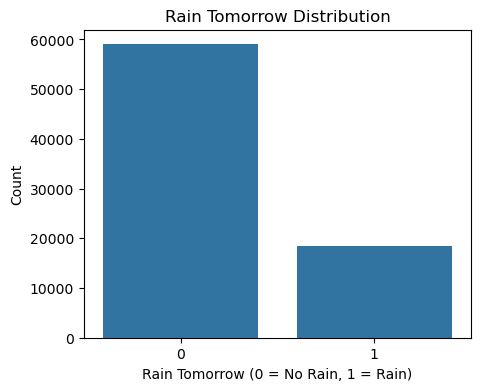


Model Comparison:



c:\Users\Harshitha Rampala\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8314163866632205
Decision Tree Accuracy: 0.7738433703799431
Random Forest Accuracy: 0.843693460842595

Final Model Accuracy: 0.841819591625743

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.90     11806
           1       0.75      0.50      0.60      3670

    accuracy                           0.84     15476
   macro avg       0.81      0.72      0.75     15476
weighted avg       0.83      0.84      0.83     15476



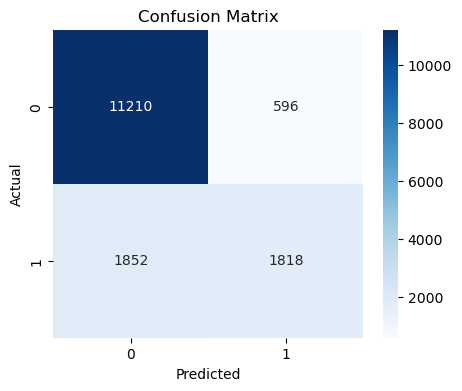


Top Features Influencing Rain:

Humidity3pm     0.197136
Cloud3pm        0.110510
Pressure3pm     0.102434
Pressure9am     0.097038
MaxTemp         0.078926
Humidity9am     0.078560
MinTemp         0.077407
Rainfall        0.072740
Cloud9am        0.056624
WindSpeed3pm    0.054922
WindSpeed9am    0.051823
RainToday       0.021881
dtype: float64


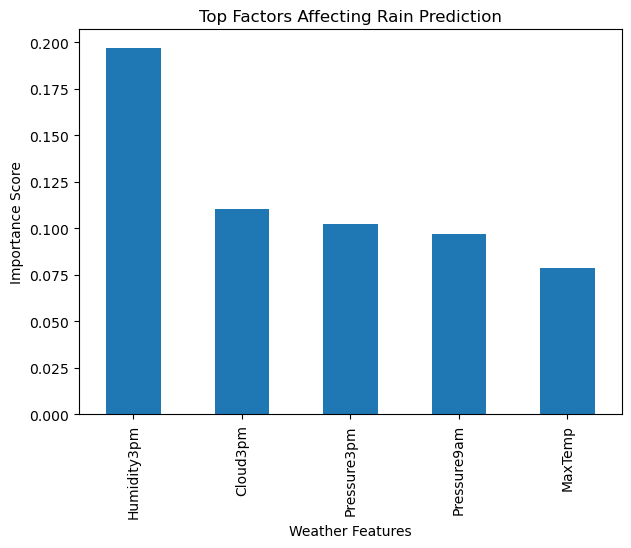


Model Saved Successfully!

Prediction Result:
Rain Tomorrow 🌧


c:\Users\Harshitha Rampala\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [13]:
# =====================================
# Rain Prediction using Machine Learning
# =====================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib


# =====================================
# Load Dataset
# =====================================

data = pd.read_csv("../data/weatherAUS.csv")

print("First 5 Rows:")
print(data.head())


# =====================================
# Dataset Overview
# =====================================

print("\nDataset Shape:", data.shape)
print("\nColumns:", data.columns)


# =====================================
# Select Important Features
# =====================================

data = data[
[
'MinTemp',
'MaxTemp',
'Rainfall',
'Humidity9am',
'Humidity3pm',
'Pressure9am',
'Pressure3pm',
'WindSpeed9am',
'WindSpeed3pm',
'Cloud9am',
'Cloud3pm',
'RainToday',
'RainTomorrow'
]
]


# =====================================
# Handle Missing Values
# =====================================

print("\nMissing Values:")
print(data.isnull().sum())

data = data.dropna()


# =====================================
# Convert Yes/No to Numeric
# =====================================

data['RainToday'] = data['RainToday'].map({'Yes':1,'No':0})
data['RainTomorrow'] = data['RainTomorrow'].map({'Yes':1,'No':0})


# =====================================
# Rain Distribution Graph
# =====================================

plt.figure(figsize=(5,4))
sns.countplot(x='RainTomorrow', data=data)
plt.title("Rain Tomorrow Distribution")
plt.xlabel("Rain Tomorrow (0 = No Rain, 1 = Rain)")
plt.ylabel("Count")
plt.show()


# =====================================
# Prepare Data
# =====================================

X = data.drop('RainTomorrow', axis=1)
y = data['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =====================================
# Model Comparison
# =====================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(class_weight="balanced")
}

print("\nModel Comparison:\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    print(name, "Accuracy:", acc)


# =====================================
# Train Final Model (Random Forest)
# =====================================

model = RandomForestClassifier(class_weight="balanced")

model.fit(X_train, y_train)

predictions = model.predict(X_test)


# =====================================
# Model Evaluation
# =====================================

accuracy = accuracy_score(y_test, predictions)

print("\nFinal Model Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))


# =====================================
# Confusion Matrix
# =====================================

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =====================================
# Feature Importance
# =====================================

importance = pd.Series(model.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

print("\nTop Features Influencing Rain:\n")
print(importance)


# Graph of top 5 features
plt.figure(figsize=(7,5))

importance.head(5).plot(kind="bar")

plt.title("Top Factors Affecting Rain Prediction")

plt.xlabel("Weather Features")

plt.ylabel("Importance Score")

plt.show()


# =====================================
# Save Model
# =====================================

joblib.dump(model, "../model/rain_model.pkl")

print("\nModel Saved Successfully!")


# =====================================
# Example Prediction
# =====================================

sample = [[20,22,10,90,85,1005,1003,30,35,8,9,1]]

prediction = model.predict(sample)

print("\nPrediction Result:")

if prediction[0] == 1:
    print("Rain Tomorrow 🌧")
else:
    print("No Rain Tomorrow ☀")